In [1]:
import numpy as np
from sklearn.preprocessing import normalize
import pandas as pd
import networkx as nx
%matplotlib inline
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)
np.set_printoptions(suppress=True) # no e notation

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xf. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.

In [2]:
def plot_graph (G,edgelabel,nodelabel,nodecolor,title):
    # Use weighted degrees in next line
    degrees = pd.DataFrame(list(G.degree(weight='weight')),columns=["node","degree"])
    plt.figure(figsize=(10,5))
    
    # Do undirected layout in next line, for some reason spring layout better than if directed.
    #layout = nx.spring_layout(G.to_undirected(), iterations=30) 
    layout = nx.kamada_kawai_layout(G)
    
    # Plot settings 
    ax = plt.gca()
    #ax.axis('off') # uncomment if you don't want the bounding box
    ax.set_title(title)
    
    # Place nodes, edges and labels
    nx.draw(G, labels=nx.get_node_attributes(G, nodelabel), pos=layout, width=0.5, 
            node_color=nodecolor, node_size=1.0*degrees["degree"]/max(degrees["degree"])*1000)
    nx.draw_networkx_edge_labels(G, pos=layout, edge_labels=nx.get_edge_attributes(G,edgelabel))
    nx.draw_networkx_edges(G, pos=layout, arrows=True, arrowsize=25)
    plt.show()

In [3]:
def PageRank(A,alpha,iter_num, verbose=False, plot=True, personalization=[]):
    node_num = len(A)
    normed_A = normalize(A, axis=1, norm='l1')
    if len(personalization) == 0:
        personalization = np.ones((node_num,node_num)) / float(node_num)
    M = normed_A * (1 - alpha) + (alpha) * personalization
    p = normalize(np.ones(node_num).reshape(1,-1),axis=1,norm='l1')
    if verbose:
        print ("normalized A: ")
        print (normed_A)
        print ("transition matrix M: ")
        print (M)
    p_states = np.copy(p)
    for i in range(iter_num):
        p = np.dot(p,M)
        p_states = np.concatenate((p_states,p))
        
    if plot:
        plt.figure(figsize=(10,3))
        for i in range(node_num):
            plt.plot(range(iter_num+1),p_states[:,i])
        plt.show
    return p_states

# Directed, undirected, weighted

## Toy graph

In [4]:
toy_pd=pd.DataFrame([[0, 1, 1],
                      [1, 2, 1],
                      [2, 3, 1],
                      [0, 3, 1],
                      [3, 1, 1]],
                     columns=["source","target","weight"])
toy_pd

,source,target,weight
0,0,1,1
1,1,2,1
2,2,3,1
3,0,3,1
4,3,1,1


In [5]:
G=nx.from_pandas_edgelist(toy_pd, edge_attr='weight', create_using=nx.DiGraph())
A=nx.to_numpy_array(G)
A

array([[0., 1., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

normalized A: 
[[0.  0.5 0.  0.5]
 [0.  0.  1.  0. ]
 [0.  0.  0.  1. ]
 [0.  1.  0.  0. ]]
transition matrix M: 
[[0.2 0.3 0.2 0.3]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.2 0.4]
 [0.2 0.4 0.2 0.2]]


array([[0.25, 0.25, 0.25, 0.25],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27],
       [0.2 , 0.27, 0.25, 0.27]])

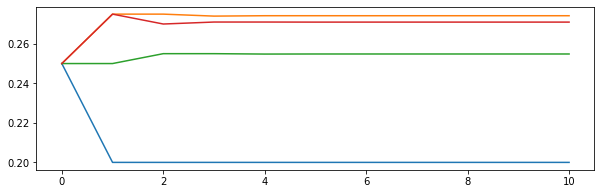

In [6]:
iterations=10
pr = PageRank(A, 0.8, iterations, verbose=True)
pr

In [7]:
nx.set_node_attributes(G, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

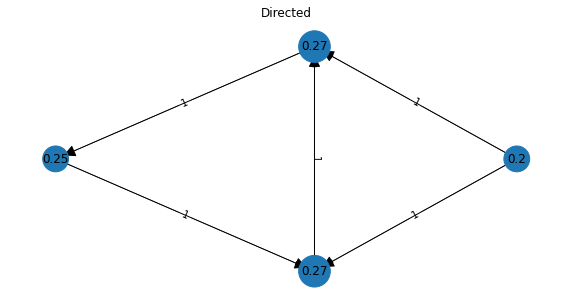

In [8]:
plot_graph(G, 'weight', 'pagerank', None, 'Directed')

## Weighted

In [9]:
weight=10

In [10]:
w_toy_pd=pd.DataFrame([[0, 1, weight],
                      [1, 2, 1],
                      [2, 3, 1],
                      [0, 3, 1],
                      [3, 1, 1]],
                     columns=["source","target","weight"])
w_toy_pd

,source,target,weight
0,0,1,10
1,1,2,1
2,2,3,1
3,0,3,1
4,3,1,1


In [11]:
G=nx.from_pandas_edgelist(w_toy_pd, edge_attr='weight', create_using=nx.DiGraph())
A=nx.to_numpy_array(G)
A

array([[ 0., 10.,  0.,  1.],
       [ 0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  1.],
       [ 0.,  1.,  0.,  0.]])

normalized A: 
[[0.   0.91 0.   0.09]
 [0.   0.   1.   0.  ]
 [0.   0.   0.   1.  ]
 [0.   1.   0.   0.  ]]
transition matrix M: 
[[0.2  0.38 0.2  0.22]
 [0.2  0.2  0.4  0.2 ]
 [0.2  0.2  0.2  0.4 ]
 [0.2  0.4  0.2  0.2 ]]


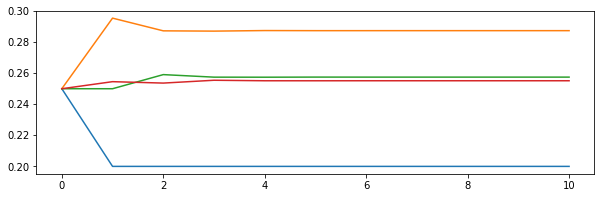

In [12]:
iterations=10
pr = PageRank(A, 0.8, iterations, verbose=True)

In [13]:
nx.set_node_attributes(G, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

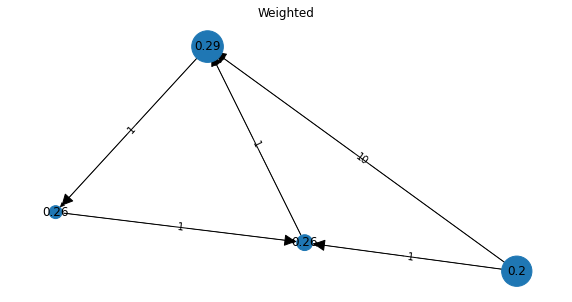

In [14]:
plot_graph(G, 'weight', 'pagerank', None, 'Weighted')

## Undirected graphs

In [15]:
GUndir = nx.from_pandas_edgelist(toy_pd,edge_attr='weight', create_using=nx.Graph())
A=nx.to_numpy_array(GUndir,weight=None)
A

array([[0., 1., 0., 1.],
       [1., 0., 1., 1.],
       [0., 1., 0., 1.],
       [1., 1., 1., 0.]])

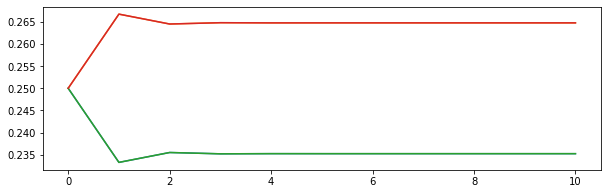

In [16]:
iterations=10
pr = PageRank(A, 0.8, iterations)

In [17]:
nx.set_node_attributes(GUndir, dict(zip(GUndir.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

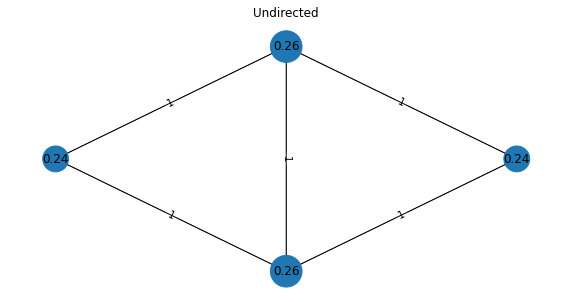

In [18]:
plot_graph(GUndir, 'weight', 'pagerank', None, 'Undirected')

# Zero degree

In [19]:
z_toy_pd=pd.DataFrame([[0, 1, 1],
                      [1, 2, 1],
                      #[2, 3, weight],
                      [0, 3, 1],
                      [3, 1, 1]],
                     columns=["source","target","weight"])
z_toy_pd

,source,target,weight
0,0,1,1
1,1,2,1
2,0,3,1
3,3,1,1


In [20]:
G=nx.from_pandas_edgelist(z_toy_pd, edge_attr='weight', create_using=nx.DiGraph())
A=nx.to_numpy_array(G)
A

array([[0., 1., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 0., 0.],
       [0., 1., 0., 0.]])

normalized A: 
[[0.  0.5 0.  0.5]
 [0.  0.  1.  0. ]
 [0.  0.  0.  0. ]
 [0.  1.  0.  0. ]]
transition matrix M: 
[[0.2 0.3 0.2 0.3]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.2 0.2]
 [0.2 0.4 0.2 0.2]]


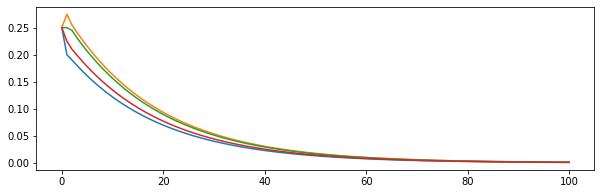

In [21]:
iterations=100 # More iterations, slower convergence, goes down to Zero!
pr = PageRank(A, 0.8, iterations, verbose=True)

In [22]:
nx.set_node_attributes(G, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

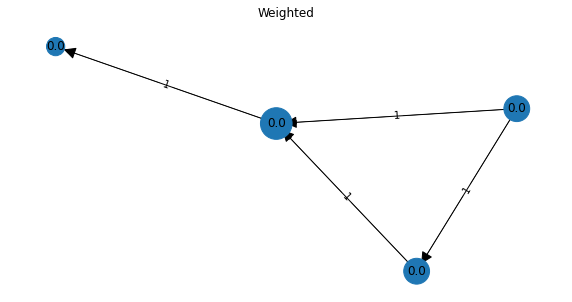

In [23]:
plot_graph(G, 'weight', 'pagerank', None, 'Weighted')

# Negative weights, Distrust

## PageRank does not work with negative weights without modification

In [24]:
weight=-1

In [25]:
nw_toy_pd=pd.DataFrame([[0, 1, 1],
                      [1, 2, 1],
                      [2, 3, weight],
                      [0, 3, 1],
                      [3, 1, 1]],
                     columns=["source","target","weight"])
nw_toy_pd

,source,target,weight
0,0,1,1
1,1,2,1
2,2,3,-1
3,0,3,1
4,3,1,1


In [26]:
G=nx.from_pandas_edgelist(nw_toy_pd, edge_attr='weight', create_using=nx.DiGraph())
A=nx.to_numpy_array(G)
A

array([[ 0.,  1.,  0.,  1.],
       [ 0.,  0.,  1.,  0.],
       [ 0.,  0.,  0., -1.],
       [ 0.,  1.,  0.,  0.]])

normalized A: 
[[ 0.   0.5  0.   0.5]
 [ 0.   0.   1.   0. ]
 [ 0.   0.   0.  -1. ]
 [ 0.   1.   0.   0. ]]
transition matrix M: 
[[0.2 0.3 0.2 0.3]
 [0.2 0.2 0.4 0.2]
 [0.2 0.2 0.2 0. ]
 [0.2 0.4 0.2 0.2]]


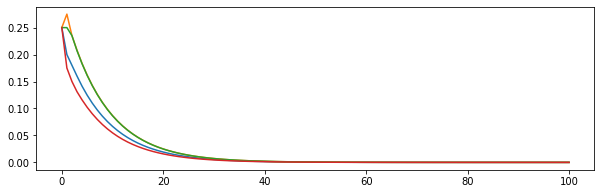

In [27]:
iterations=100 # More iterations, slower convergence, goes down to Zero!
pr = PageRank(A, 0.8, iterations, verbose=True)

In [28]:
nx.set_node_attributes(G, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

/home/benczur/.local/lib/python3.9/site-packages/networkx/drawing/layout.py:724: RuntimeWarning: divide by zero encountered in true_divide
  costargs = (np, 1 / (dist_mtx + np.eye(dist_mtx.shape[0]) * 1e-3), meanwt, dim)
/home/benczur/.local/lib/python3.9/site-packages/networkx/drawing/layout.py:750: RuntimeWarning: invalid value encountered in subtract
  grad = np.einsum("ij,ij,ijk->ik", invdist, offset, direction) - np.einsum(


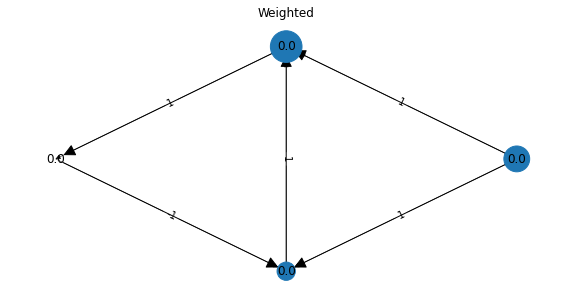

In [29]:
# Error: zero weighted degree
plot_graph(G, 'weight', 'pagerank', None, 'Weighted')

## Ignore negative - undirected to avoid zero degree

In [30]:
G=nx.from_pandas_edgelist(nw_toy_pd, edge_attr='weight', create_using=nx.Graph())
for u, v in G.edges():
    if G.edges[u, v]['weight'] < 0:
        G.remove_edge (u, v)
Apos=nx.to_numpy_array(G)
Apos

array([[0., 1., 0., 1.],
       [1., 0., 1., 1.],
       [0., 1., 0., 0.],
       [1., 1., 0., 0.]])

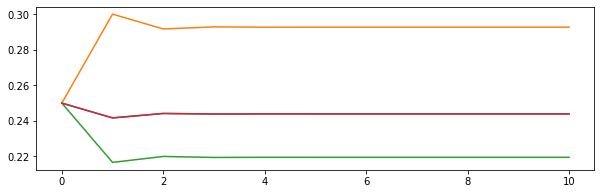

In [31]:
iterations=10
pr = PageRank(Apos, 0.8, iterations)

In [32]:
nx.set_node_attributes(G, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

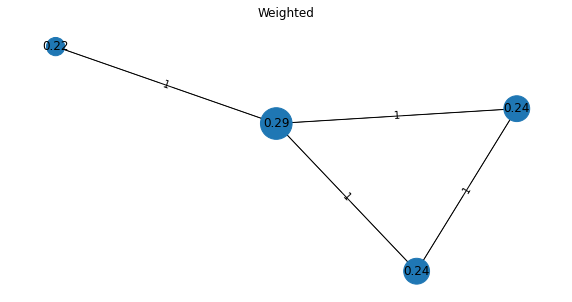

In [33]:
plot_graph(G, 'weight', 'pagerank', None, 'Weighted')

## Trustrank: trust if no negative weight enters

In [34]:
G=nx.from_pandas_edgelist(nw_toy_pd, edge_attr='weight', create_using=nx.DiGraph())

In [35]:
trust=np.ones(G.number_of_nodes())
distrust=np.zeros(G.number_of_nodes())
for u, v in G.edges():
    if G.edges[u, v]['weight'] < 0:
        trust[v] = 0
        distrust[v] = 1
trust=trust/sum(trust)
distrust=distrust/sum(distrust)
trust,distrust

(array([0.33, 0.33, 0.33, 0.  ]), array([0., 0., 0., 1.]))

In [36]:
Gorig=G.copy()
for u, v in Gorig.edges():
    if G.edges[u, v]['weight'] < 0:
        G.remove_edge (u, v)
Apos=nx.to_numpy_array(G)
Apos

array([[0., 1., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 0., 0.],
       [0., 1., 0., 0.]])

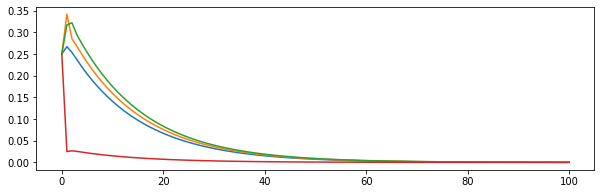

In [37]:
iterations=100
pr = PageRank(Apos, 0.8, iterations, personalization = trust)

In [38]:
nx.set_node_attributes(Gorig, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

/home/benczur/.local/lib/python3.9/site-packages/networkx/drawing/layout.py:724: RuntimeWarning: divide by zero encountered in true_divide
  costargs = (np, 1 / (dist_mtx + np.eye(dist_mtx.shape[0]) * 1e-3), meanwt, dim)
/home/benczur/.local/lib/python3.9/site-packages/networkx/drawing/layout.py:750: RuntimeWarning: invalid value encountered in subtract
  grad = np.einsum("ij,ij,ijk->ik", invdist, offset, direction) - np.einsum(


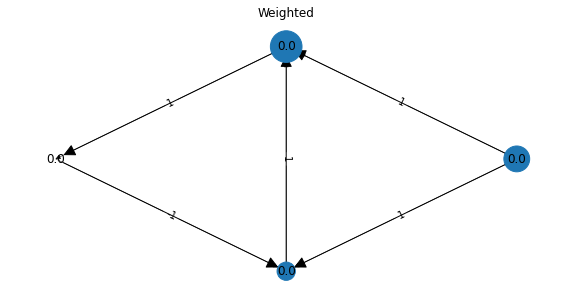

In [39]:
plot_graph(Gorig, 'weight', 'pagerank', None, 'Weighted')

## Distrust along reversed edges

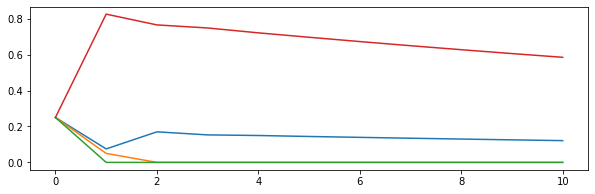

In [40]:
iterations=10
pr = PageRank(np.transpose(Apos), 0.8, iterations, personalization = distrust)

In [41]:
nx.set_node_attributes(Gorig, dict(zip(G.nodes, np.around(pr[iterations], decimals=2))), 'pagerank')

/home/benczur/.local/lib/python3.9/site-packages/networkx/drawing/layout.py:724: RuntimeWarning: divide by zero encountered in true_divide
  costargs = (np, 1 / (dist_mtx + np.eye(dist_mtx.shape[0]) * 1e-3), meanwt, dim)
/home/benczur/.local/lib/python3.9/site-packages/networkx/drawing/layout.py:750: RuntimeWarning: invalid value encountered in subtract
  grad = np.einsum("ij,ij,ijk->ik", invdist, offset, direction) - np.einsum(


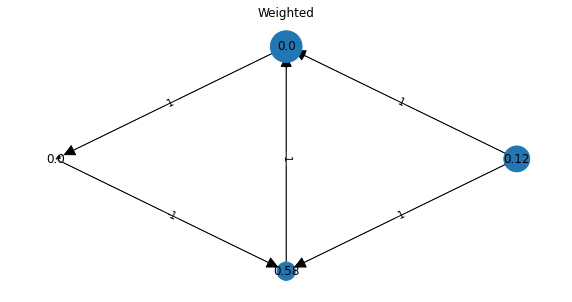

In [42]:
plot_graph(Gorig, 'weight', 'pagerank', None, 'Weighted')

# Temporal graph plot

In [43]:
import time
import pylab as pl
from IPython import display
%matplotlib inline

In [44]:
def random_graph (n, p):
    G = nx.Graph()
    for i in range(0, n):
        G.add_node(i)
        
    for i in range(0, n):
        for j in range(i+1, n):
            if np.random.choice([True, False], p=[p, 1-p]):
                G.add_edge(i, j)
    return G    

In [45]:
#Draws the whole graph but only a subgraph is visible
def draw_subgraph(G, init_num, pos, interv=1):
    for sub in range(init_num, len(G.nodes), interv):
        plt.figure(figsize=(20,10))
        T = nx.subgraph(G, range(sub))
        node_size = []
        node_color = []
        edge_color = []

        for i in T.nodes:
            node_color.append((1, max(0.5-T.degree(i)/100, 0), max(0.5-T.degree(i)/100, 0)))
            node_size.append(T.degree(i)*20)
            edge_color.append("black")
            
        for i in range(sub, len(G.nodes)):
            node_color.append((0, 0, 0))
            node_size.append(0)
            edge_color.append("white")
        nx.draw(G, pos, nodelist=G.nodes, node_size=node_size, node_color=node_color, edge_color="white")
        nx.draw_networkx_edges(G, pos, edgelist=list(T.edges), edge_color=list(["black" for _ in range(len(T.edges))]))
        plt.draw()
        yield

In [46]:
G = random_graph(100, 0.3)
pos = nx.spring_layout(G, k=0.25)
a = draw_subgraph(G, 5, pos)

In [47]:
while True:
    try:
        pl.clf()
        next(a)
        display.display(pl.gcf())
        display.clear_output(wait=True)
        plt.close()
        time.sleep(0.1)
    except KeyboardInterrupt:
        break
    except StopIteration:
        break

<Figure size 432x288 with 0 Axes>

# Bipartite layout

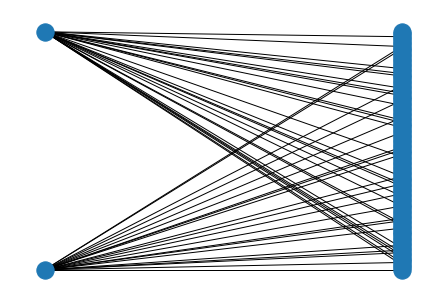

In [48]:
nx.draw(G, pos=nx.bipartite_layout(G,[0,1]))

# Compute Hubs and Authorities for a signed graph

In [49]:
A=[[0,1,0,1],
  [0,0,-1,-1],
  [-1,0,0,0],
  [0,1,0,1]]
AT=np.transpose(A)

In [50]:
h=np.ones(len(A))

In [51]:
print (np.dot(A,AT))

[[ 2 -1  0  2]
 [-1  2  0 -1]
 [ 0  0  1  0]
 [ 2 -1  0  2]]


In [52]:
a=np.dot(h,A)
print (a)

[-1.  2. -1.  1.]


In [53]:
h=np.dot (a,AT)
print (h)

[3. 0. 1. 3.]


In [54]:
np.dot(np.linalg.matrix_power(np.dot(A,AT),10),np.ones(len(A)))

array([ 2814912., -2060640.,        1.,  2814912.])

# Compare results with SVD

In [55]:
U, w, V = np.linalg.svd(A, full_matrices=True)
W = np.diag(w)
print ("First Hub vector is", U[:,0])

First Hub vector is [-0.63  0.46  0.   -0.63]


In [56]:
-U

array([[ 0.63, -0.33, -0.  ,  0.71],
       [-0.46, -0.89, -0.  , -0.  ],
       [-0.  , -0.  , -1.  , -0.  ],
       [ 0.63, -0.33, -0.  , -0.71]])

In [57]:
w

array([2.18, 1.13, 1.  , 0.  ])

# Sample visualization with singular vector pairs from U

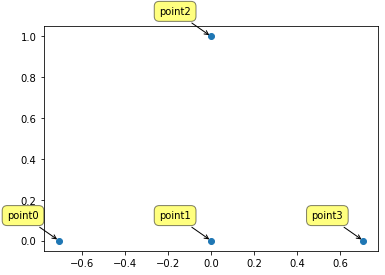

In [58]:
# Scatter plot of pairs of singular vectors
X = U[:,3]
Y = U[:,2]
%matplotlib inline
import matplotlib.pyplot as plt
N, _ = np.shape(U)
labels = ['point{0}'.format(i) for i in range(N)]
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X, Y, marker = 'o')
for label, x, y in zip(labels, X, Y):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (-20, 20),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        bbox = dict(boxstyle = 'round,pad=0.5', fc = 'yellow', alpha = 0.5),
        arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0'))

plt.show()

In [59]:
G=nx.from_numpy_array(np.matrix(A))

In [60]:
def plot_graph_2D (G,X,Y):   
    layout = dict(zip(list(G.nodes),zip(X,Y)))
    nx.draw(G, with_labels=True, pos=layout, width=0.5)
    nx.draw_networkx_edges(G, pos=layout, arrows=True, arrowsize=20)
    plt.show()

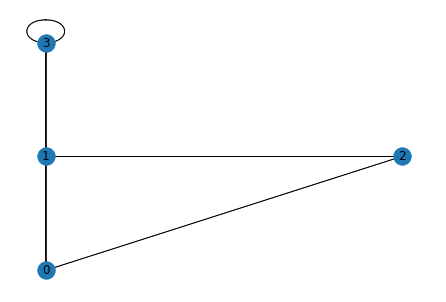

In [61]:
plot_graph_2D (G, U[:,2], U[:,3])